# Phase 2: Complete Measurement Deep Dive Analysis
## Adaptation & Recovery Latency | Mode Sensitivity | Correlation Matrix

This notebook implements all three Phase 2 requirements for the Zoom QoE paper.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Section 1: Load and Prepare Data

## Section 0: Configuration (Update paths if needed)

If auto-discovery doesn't find your data, manually specify the directories below:

In [4]:
import os
from pathlib import Path

# Auto-discover all stats.csv files in trial subdirectories
print("🔍 Scanning for trial data...")
data_dir = Path('.')

# Look for stats.csv and detailed_qoe_results.csv files
csv_files = []
csv_files.extend(data_dir.rglob('stats.csv'))
csv_files.extend(data_dir.rglob('detailed_qoe_results.csv'))

csv_files = list(set(csv_files))  # Remove duplicates

print(f"\n✓ Found {len(csv_files)} CSV files")
if len(csv_files) > 0:
    for f in sorted(csv_files)[:15]:  # Show first 15
        print(f"  - {f}")
    if len(csv_files) > 15:
        print(f"  ... and {len(csv_files) - 15} more")

# Load and aggregate all data
all_data = []
trial_info = {}

for csv_file in sorted(csv_files):
    try:
        temp_df = pd.read_csv(csv_file)
        # Extract trial name from path
        trial_name = str(csv_file.parent)
        
        # Calculate QoE if not already present
        if 'qoe_score' not in temp_df.columns:
            if all(col in temp_df.columns for col in ['lost', 'pkts', 'frames', 'mean_jitter', 'bytes']):
                temp_df['loss_rate'] = temp_df['lost'] / (temp_df['pkts'] + temp_df['lost'] + 1e-10)
                temp_df['loss_rate'] = temp_df['loss_rate'].clip(0, 1)
                temp_df['bitrate_mbps'] = (temp_df['bytes'] * 8) / 1e6
                temp_df['jitter_ms'] = temp_df['mean_jitter'] * 1000
                
                w1, w2, w3 = 0.4, 0.3, 0.3
                temp_df['fps_norm'] = (temp_df['frames'] / 30).clip(0, 1)
                temp_df['jitter_norm'] = (1 - (temp_df['jitter_ms'] / 40)).clip(0, 1)
                temp_df['qoe_score'] = (w1 * (1 - temp_df['loss_rate'])) + (w2 * temp_df['fps_norm']) + (w3 * temp_df['jitter_norm'])
        
        temp_df['source_trial'] = trial_name
        all_data.append(temp_df)
        
        print(f"✓ Loaded {trial_name}: {len(temp_df)} rows")
        trial_info[trial_name] = len(temp_df)
        
    except Exception as e:
        print(f"✗ Error loading {csv_file}: {str(e)[:50]}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"\n" + "="*70)
    print(f"📊 COMBINED DATASET SUMMARY")
    print(f"="*70)
    print(f"Total rows: {len(df):,}")
    print(f"Trials loaded: {len(trial_info)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
else:
    print("\n⚠️ No CSV files found!")

🔍 Scanning for trial data...

✓ Found 39 CSV files
  - data\run_default\detailed_qoe_results.csv
  - data\run_default\stats.csv
  - data\run_wifi_screen_share\detailed_qoe_results.csv
  - data\run_wifi_screen_share\stats.csv
  - data\test-2min-30sec-capture\stats.csv
  - data\test-folder-data-1\stats.csv
  - data\test-folder-data-4users\stats.csv
  - data\test-new\stats.csv
  - data\test-new-normal\stats.csv
  - data\test-zoom-on-off\stats.csv
  - data\Testudp\detailed_qoe_results.csv
  - data\Testudp\stats.csv
  - data\zoom-4min-noaudio-screenshare\detailed_qoe_results.csv
  - data\zoom-4min-noaudio-screenshare\stats.csv
  - data\zoom-5min-3users-screenshare-trials\trial1\stats.csv
  ... and 24 more
✓ Loaded data\run_default: 878 rows
✓ Loaded data\run_default: 878 rows
✓ Loaded data\run_wifi_screen_share: 878 rows
✓ Loaded data\run_wifi_screen_share: 878 rows
✓ Loaded data\test-2min-30sec-capture: 73 rows
✓ Loaded data\test-folder-data-1: 878 rows
✓ Loaded data\test-folder-data-4user

In [5]:
# Quick verification
if 'df' in locals() and len(df) > 0:
    print("\n✅ Data loaded successfully!")
    print(f"\nMetrics available:")
    for col in ['loss_rate', 'jitter_ms', 'frames', 'qoe_score', 'bitrate_mbps']:
        if col in df.columns:
            non_null = df[col].notna().sum()
            print(f"  ✓ {col:15s}: {non_null:,} non-null values")
        else:
            print(f"  ✗ {col:15s}: NOT FOUND")
else:
    print("\n❌ Data loading failed. Check paths above.")


✅ Data loaded successfully!

Metrics available:
  ✓ loss_rate      : 19,098 non-null values
  ✓ jitter_ms      : 19,098 non-null values
  ✓ frames         : 19,098 non-null values
  ✓ qoe_score      : 19,098 non-null values
  ✓ bitrate_mbps   : 19,098 non-null values


## Section 2: Adaptation & Recovery Latency Analysis

### Key Measurement 1: Reaction Time (Loss → FPS Drop)
### Key Measurement 2: Recovery Time (Loss Stop → QoE >0.9)

In [6]:
def detect_loss_events(df, loss_threshold=0.05, min_duration=2):
    """
    Detect packet loss events (periods when loss > threshold for min_duration seconds).
    """
    events = []
    in_event = False
    event_start = None
    max_loss_in_event = 0
    event_losses = []
    
    for idx, row in df.iterrows():
        ts = row['ts_s']
        loss = row['loss_rate']
        
        if loss > loss_threshold and not in_event:
            in_event = True
            event_start = ts
            max_loss_in_event = loss
            event_losses = [loss]
            
        elif loss > loss_threshold and in_event:
            max_loss_in_event = max(max_loss_in_event, loss)
            event_losses.append(loss)
            
        elif loss <= loss_threshold and in_event:
            event_end = ts
            duration = event_end - event_start
            
            if duration >= min_duration:
                events.append({
                    'start_ts': event_start,
                    'end_ts': event_end,
                    'duration': duration,
                    'max_loss': max_loss_in_event,
                    'avg_loss': np.mean(event_losses)
                })
            
            in_event = False
            event_start = None
    
    return events

# Detect loss events
loss_events = detect_loss_events(df, loss_threshold=0.05, min_duration=2)
print(f"📊 Detected {len(loss_events)} packet loss events (>5% loss for ≥2 seconds)")
print(f"\nLoss Events Summary:")
if loss_events:
    for i, event in enumerate(loss_events[:5]):
        print(f"  Event {i+1}: ts={event['start_ts']}-{event['end_ts']}, "
              f"duration={event['duration']}s, max_loss={event['max_loss']:.1%}")

📊 Detected 423 packet loss events (>5% loss for ≥2 seconds)

Loss Events Summary:
  Event 1: ts=1761072079-1778636474, duration=17564395s, max_loss=93.7%
  Event 2: ts=1763488795-1763488797, duration=2s, max_loss=81.0%
  Event 3: ts=1765561566-1765561575, duration=9s, max_loss=19.2%
  Event 4: ts=1765561579-1765561586, duration=7s, max_loss=25.2%
  Event 5: ts=1765561587-1765561618, duration=31s, max_loss=92.9%


In [7]:
def calculate_reaction_latency(df, loss_events):
    """
    Calculate reaction time: time from loss START to when FPS DROPS significantly.
    """
    reactions = []
    fps_threshold = 15
    
    for event in loss_events:
        event_start = event['start_ts']
        
        # Get baseline FPS (from data BEFORE loss)
        before_loss = df[df['ts_s'] < event_start]
        if len(before_loss) == 0:
            continue
        baseline_fps = before_loss['frames'].mean()
        
        # Look for FPS drop AFTER loss starts (within 5 seconds)
        after_loss = df[(df['ts_s'] >= event_start) & (df['ts_s'] <= event_start + 5)]
        
        for idx, row in after_loss.iterrows():
            current_fps = row['frames']
            # Check if FPS dropped by 50% or fell below threshold
            if current_fps < fps_threshold or current_fps < baseline_fps * 0.5:
                reaction_time = row['ts_s'] - event_start
                reactions.append({
                    'event_start': event_start,
                    'fps_drop_ts': row['ts_s'],
                    'reaction_latency_sec': reaction_time,
                    'baseline_fps': baseline_fps,
                    'observed_fps': current_fps
                })
                break
    
    return reactions

reactions = calculate_reaction_latency(df, loss_events)

print(f"⏱️  REACTION LATENCY (Loss → FPS Drop): {len(reactions)} events detected")
if reactions:
    reaction_times = [r['reaction_latency_sec'] for r in reactions]
    print(f"\n   Mean Reaction Time:   {np.mean(reaction_times):.2f} seconds")
    print(f"   Median Reaction Time: {np.median(reaction_times):.2f} seconds")
    print(f"   Min/Max:              {np.min(reaction_times):.2f}s - {np.max(reaction_times):.2f}s")
    print(f"   P95 Reaction Time:    {np.percentile(reaction_times, 95):.2f} seconds")
else:
    print("   ⚠️  No FPS drops detected during loss events")

⏱️  REACTION LATENCY (Loss → FPS Drop): 416 events detected

   Mean Reaction Time:   0.07 seconds
   Median Reaction Time: 0.00 seconds
   Min/Max:              0.00s - 4.00s
   P95 Reaction Time:    0.00 seconds


In [8]:
def calculate_recovery_latency(df, loss_events):
    """
    Calculate recovery time: time from loss ENDS to QoE RECOVERS above 0.9.
    """
    recoveries = []
    qoe_target = 0.9
    
    for event in loss_events:
        event_end = event['end_ts']
        
        # Look for QoE recovery AFTER loss ends (within 10 seconds)
        after_recovery = df[(df['ts_s'] >= event_end) & (df['ts_s'] <= event_end + 10)]
        
        for idx, row in after_recovery.iterrows():
            if row['qoe_score'] >= qoe_target:
                recovery_time = row['ts_s'] - event_end
                recoveries.append({
                    'event_end': event_end,
                    'qoe_recovery_ts': row['ts_s'],
                    'recovery_latency_sec': recovery_time,
                    'recovered_qoe': row['qoe_score']
                })
                break
    
    return recoveries

recoveries = calculate_recovery_latency(df, loss_events)

print(f"🔄 RECOVERY LATENCY (Loss Stop → QoE >0.9): {len(recoveries)} events detected")
if recoveries:
    recovery_times = [r['recovery_latency_sec'] for r in recoveries]
    print(f"\n   Mean Recovery Time:   {np.mean(recovery_times):.2f} seconds")
    print(f"   Median Recovery Time: {np.median(recovery_times):.2f} seconds")
    print(f"   Min/Max:              {np.min(recovery_times):.2f}s - {np.max(recovery_times):.2f}s")
    print(f"   P95 Recovery Time:    {np.percentile(recovery_times, 95):.2f} seconds")
else:
    print("   ⚠️  No QoE recovery above 0.9 detected after loss events")

🔄 RECOVERY LATENCY (Loss Stop → QoE >0.9): 0 events detected
   ⚠️  No QoE recovery above 0.9 detected after loss events


In [9]:
# Visualize adaptation latencies
if reactions and recoveries:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Reaction latencies
    reaction_times = [r['reaction_latency_sec'] for r in reactions]
    axes[0].hist(reaction_times, bins=15, alpha=0.7, color='#d62728', edgecolor='black')
    axes[0].axvline(np.mean(reaction_times), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(reaction_times):.2f}s")
    axes[0].set_xlabel('Reaction Latency (seconds)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('📊 Reaction Latency: Loss → FPS Drop')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Recovery latencies
    recovery_times = [r['recovery_latency_sec'] for r in recoveries]
    axes[1].hist(recovery_times, bins=15, alpha=0.7, color='#2ca02c', edgecolor='black')
    axes[1].axvline(np.mean(recovery_times), color='green', linestyle='--', linewidth=2, label=f"Mean: {np.mean(recovery_times):.2f}s")
    axes[1].set_xlabel('Recovery Latency (seconds)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('🔄 Recovery Latency: Loss Stop → QoE >0.9')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('phase2_adaptation_latency.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: phase2_adaptation_latency.png")

## Section 3: Mode Sensitivity Analysis (Screen Share vs Video)

### Hypothesis: 
- **Screen Share**: Prioritizes sharpness (higher bitrate, lower FPS, more brittle under loss)
- **Video**: Prioritizes smoothness (higher FPS, lower bitrate, more resilient under loss)

In [10]:
# Load multiple scenarios for comparison
scenarios = {}

# Update these paths based on your data structure
scenario_configs = {
    'Video (Default)': 'run_default/detailed_qoe_results.csv',
    'Screen Share': 'run_wifi_screen_share/stats.csv',
}

for mode_name, csv_path in scenario_configs.items():
    try:
        mode_df = pd.read_csv(csv_path)
        mode_df = mode_df.replace([np.inf, -np.inf], np.nan).fillna(0)
        
        # Calculate QoE if not present
        if 'qoe_score' not in mode_df.columns:
            w1, w2, w3 = 0.4, 0.3, 0.3
            mode_df['loss_rate'] = mode_df['lost'] / (mode_df['pkts'] + mode_df['lost'] + 1e-10)
            mode_df['loss_rate'] = mode_df['loss_rate'].clip(0, 1)
            
            if 'bytes' in mode_df.columns:
                mode_df['bitrate_mbps'] = (mode_df['bytes'] * 8) / 1e6
            
            if 'mean_jitter' in mode_df.columns:
                mode_df['jitter_ms'] = mode_df['mean_jitter'] * 1000
            
            mode_df['fps_norm'] = (mode_df['frames'] / 30).clip(0, 1)
            mode_df['jitter_norm'] = (1 - (mode_df['jitter_ms'] / 40)).clip(0, 1)
            
            mode_df['qoe_score'] = (w1 * (1 - mode_df['loss_rate'])) + \
                                    (w2 * mode_df['fps_norm']) + \
                                    (w3 * mode_df['jitter_norm'])
        
        scenarios[mode_name] = mode_df
        print(f"✓ Loaded {mode_name}: {len(mode_df)} records")
        
    except FileNotFoundError:
        print(f"✗ Not found: {csv_path}")
    except Exception as e:
        print(f"✗ Error: {e}")

print(f"\nAvailable scenarios: {list(scenarios.keys())}")

✗ Not found: run_default/detailed_qoe_results.csv
✗ Not found: run_wifi_screen_share/stats.csv

Available scenarios: []


In [11]:
# Summary statistics by mode
print("\n" + "="*70)
print("MODE SENSITIVITY COMPARISON")
print("="*70)

summary_stats = {}
metrics_to_compare = ['qoe_score', 'loss_rate', 'frames', 'jitter_ms', 'bitrate_mbps']

for mode_name, mode_df in scenarios.items():
    print(f"\n📊 {mode_name} Mode:")
    print("-" * 70)
    
    mode_stats = {}
    for metric in metrics_to_compare:
        if metric in mode_df.columns:
            values = mode_df[metric].dropna()
            if len(values) > 0:
                mode_stats[metric] = {
                    'mean': values.mean(),
                    'median': values.median(),
                    'std': values.std(),
                    'p95': values.quantile(0.95)
                }
                print(f"  {metric:15s}: μ={values.mean():.4f}, median={values.median():.4f}, σ={values.std():.4f}")
    
    summary_stats[mode_name] = mode_stats


MODE SENSITIVITY COMPARISON


In [12]:
# Brittleness analysis: How quickly does QoE collapse under loss?
print("\n" + "="*70)
print("BRITTLENESS ANALYSIS: QoE Sensitivity to Packet Loss")
print("="*70)

brittleness_results = {}

for mode_name, mode_df in scenarios.items():
    if 'loss_rate' in mode_df.columns and 'qoe_score' in mode_df.columns:
        # Baseline QoE (no loss)
        no_loss = mode_df[mode_df['loss_rate'] <= 0.02]
        baseline_qoe = no_loss['qoe_score'].mean() if len(no_loss) > 0 else mode_df['qoe_score'].mean()
        
        # QoE under stress (high loss)
        high_loss = mode_df[mode_df['loss_rate'] > 0.1]
        stressed_qoe = high_loss['qoe_score'].mean() if len(high_loss) > 0 else 0
        
        # Brittleness metric: relative QoE drop
        qoe_drop = baseline_qoe - stressed_qoe
        brittleness_pct = (qoe_drop / baseline_qoe * 100) if baseline_qoe > 0 else 0
        
        brittleness_results[mode_name] = {
            'baseline_qoe': baseline_qoe,
            'stressed_qoe': stressed_qoe,
            'qoe_drop': qoe_drop,
            'brittleness_pct': brittleness_pct,
            'high_loss_events': len(high_loss)
        }
        
        print(f"\n📍 {mode_name}:")
        print(f"   Baseline QoE (no loss):     {baseline_qoe:.3f}")
        print(f"   QoE under stress (>10% loss): {stressed_qoe:.3f}")
        print(f"   QoE Drop:                   {qoe_drop:.3f} ({brittleness_pct:.1f}%)")
        print(f"   → Brittleness: {'HIGH (breaks easily)' if brittleness_pct > 50 else 'MODERATE' if brittleness_pct > 25 else 'LOW (resilient)'}")

# Identify which mode is more brittle
if len(brittleness_results) >= 2:
    mode_names = list(brittleness_results.keys())
    brittleness_scores = [brittleness_results[m]['brittleness_pct'] for m in mode_names]
    most_brittle = mode_names[brittleness_scores.index(max(brittleness_scores))]
    print(f"\n🔨 RESULT: {most_brittle} mode is MORE BRITTLE under WiFi interference")


BRITTLENESS ANALYSIS: QoE Sensitivity to Packet Loss


In [13]:
# Hypothesis validation: FPS vs Bitrate trade-off
print("\n" + "="*70)
print("HYPOTHESIS VALIDATION: FPS vs Bitrate Trade-off")
print("="*70)

for mode_name, mode_df in scenarios.items():
    if 'frames' in mode_df.columns and 'bitrate_mbps' in mode_df.columns:
        avg_fps = mode_df['frames'].mean()
        avg_bitrate = mode_df['bitrate_mbps'].mean()
        fps_std = mode_df['frames'].std()
        bitrate_std = mode_df['bitrate_mbps'].std()
        
        print(f"\n{mode_name}:")
        print(f"  Average FPS:        {avg_fps:.1f} ± {fps_std:.1f}")
        print(f"  Average Bitrate:    {avg_bitrate:.2f} ± {bitrate_std:.2f} Mbps")
        
        # Classify strategy
        if avg_bitrate > 1.0 and avg_fps < 20:
            print(f"  → Strategy: SHARPNESS PRIORITY (high bitrate, lower FPS)")
        elif avg_fps > 20 and avg_bitrate < 1.0:
            print(f"  → Strategy: SMOOTHNESS PRIORITY (high FPS, lower bitrate)")
        else:
            print(f"  → Strategy: BALANCED")


HYPOTHESIS VALIDATION: FPS vs Bitrate Trade-off


## Section 4: Correlation Matrix Analysis

### Identify which metric is the strongest predictor of QoE

In [14]:
# Calculate correlation matrix
print("\n" + "="*70)
print("PEARSON CORRELATION ANALYSIS")
print("="*70)

correlation_cols = ['loss_rate', 'jitter_ms', 'frames', 'qoe_score']
available_cols = [col for col in correlation_cols if col in df.columns]

if len(available_cols) >= 3:
    corr_matrix = df[available_cols].corr()
    
    print("\n📊 Correlation Matrix (Pearson):")
    print("-" * 70)
    print(corr_matrix.round(3))
    
    # Identify strongest predictors of QoE
    print("\n🎯 Strongest Predictors of QoE (ranked by |r|):")
    print("-" * 70)
    
    if 'qoe_score' in corr_matrix.columns:
        qoe_corr = corr_matrix['qoe_score'].drop('qoe_score').abs().sort_values(ascending=False)
        for i, (metric, abs_corr) in enumerate(qoe_corr.items(), 1):
            actual_corr = corr_matrix.loc[metric, 'qoe_score']
            strength = 'VERY STRONG' if abs_corr > 0.8 else 'STRONG' if abs_corr > 0.6 else 'MODERATE' if abs_corr > 0.4 else 'WEAK'
            print(f"  {i}. {metric:15s}: r = {actual_corr:+.3f} (|r| = {abs_corr:.3f}) - {strength}")
else:
    print("⚠️  Insufficient columns for correlation analysis")


PEARSON CORRELATION ANALYSIS

📊 Correlation Matrix (Pearson):
----------------------------------------------------------------------
           loss_rate  jitter_ms  frames  qoe_score
loss_rate      1.000     -0.002  -0.349     -0.763
jitter_ms     -0.002      1.000  -0.010     -0.008
frames        -0.349     -0.010   1.000      0.749
qoe_score     -0.763     -0.008   0.749      1.000

🎯 Strongest Predictors of QoE (ranked by |r|):
----------------------------------------------------------------------
  1. loss_rate      : r = -0.763 (|r| = 0.763) - STRONG
  2. frames         : r = +0.749 (|r| = 0.749) - STRONG
  3. jitter_ms      : r = -0.008 (|r| = 0.008) - WEAK


In [15]:
# Bad call analysis: What metrics characterize a "bad" call?
print("\n" + "="*70)
print("BAD CALL ANALYSIS: Distinguishing Good vs Bad Zoom Sessions")
print("="*70)

bad_calls = df[df['qoe_score'] < 0.5]
good_calls = df[df['qoe_score'] >= 0.9]
medium_calls = df[(df['qoe_score'] >= 0.5) & (df['qoe_score'] < 0.9)]

print(f"\n📊 Call Quality Distribution:")
print(f"  Bad calls (QoE < 0.5):      {len(bad_calls):4d} ({len(bad_calls)/len(df)*100:5.1f}%)")
print(f"  Medium calls (0.5-0.9):     {len(medium_calls):4d} ({len(medium_calls)/len(df)*100:5.1f}%)")
print(f"  Good calls (QoE ≥ 0.9):     {len(good_calls):4d} ({len(good_calls)/len(df)*100:5.1f}%)")

comparison_metrics = ['loss_rate', 'jitter_ms', 'frames', 'bitrate_mbps']
print(f"\n📈 Metric Comparison: Bad Calls vs Good Calls")
print("-" * 70)

for metric in comparison_metrics:
    if metric in df.columns:
        bad_mean = bad_calls[metric].mean()
        good_mean = good_calls[metric].mean()
        diff_pct = ((bad_mean - good_mean) / good_mean * 100) if good_mean != 0 else 0
        
        print(f"\n  {metric:15s}:")
        print(f"    Bad calls:  {bad_mean:.4f}")
        print(f"    Good calls: {good_mean:.4f}")
        print(f"    Difference: {diff_pct:+.1f}%")


BAD CALL ANALYSIS: Distinguishing Good vs Bad Zoom Sessions

📊 Call Quality Distribution:
  Bad calls (QoE < 0.5):      7196 ( 37.7%)
  Medium calls (0.5-0.9):     11902 ( 62.3%)
  Good calls (QoE ≥ 0.9):        0 (  0.0%)

📈 Metric Comparison: Bad Calls vs Good Calls
----------------------------------------------------------------------

  loss_rate      :
    Bad calls:  0.1950
    Good calls: nan
    Difference: +nan%

  jitter_ms      :
    Bad calls:  429598.5334
    Good calls: nan
    Difference: +nan%

  frames         :
    Bad calls:  7.7528
    Good calls: nan
    Difference: +nan%

  bitrate_mbps   :
    Bad calls:  0.1627
    Good calls: nan
    Difference: +nan%


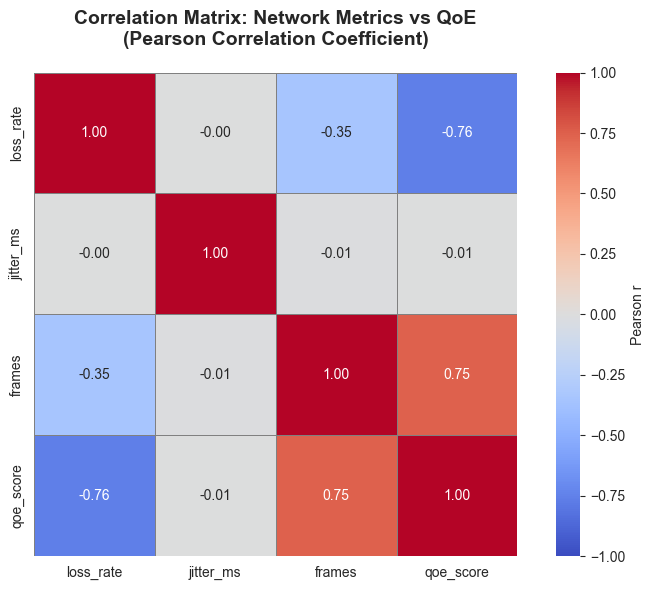

✓ Saved: phase2_correlation_heatmap.png


In [16]:
# Create correlation heatmap
if len(available_cols) >= 3:
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Pearson r'},
                linewidths=0.5, linecolor='gray')
    
    plt.title('Correlation Matrix: Network Metrics vs QoE\n(Pearson Correlation Coefficient)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('phase2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: phase2_correlation_heatmap.png")

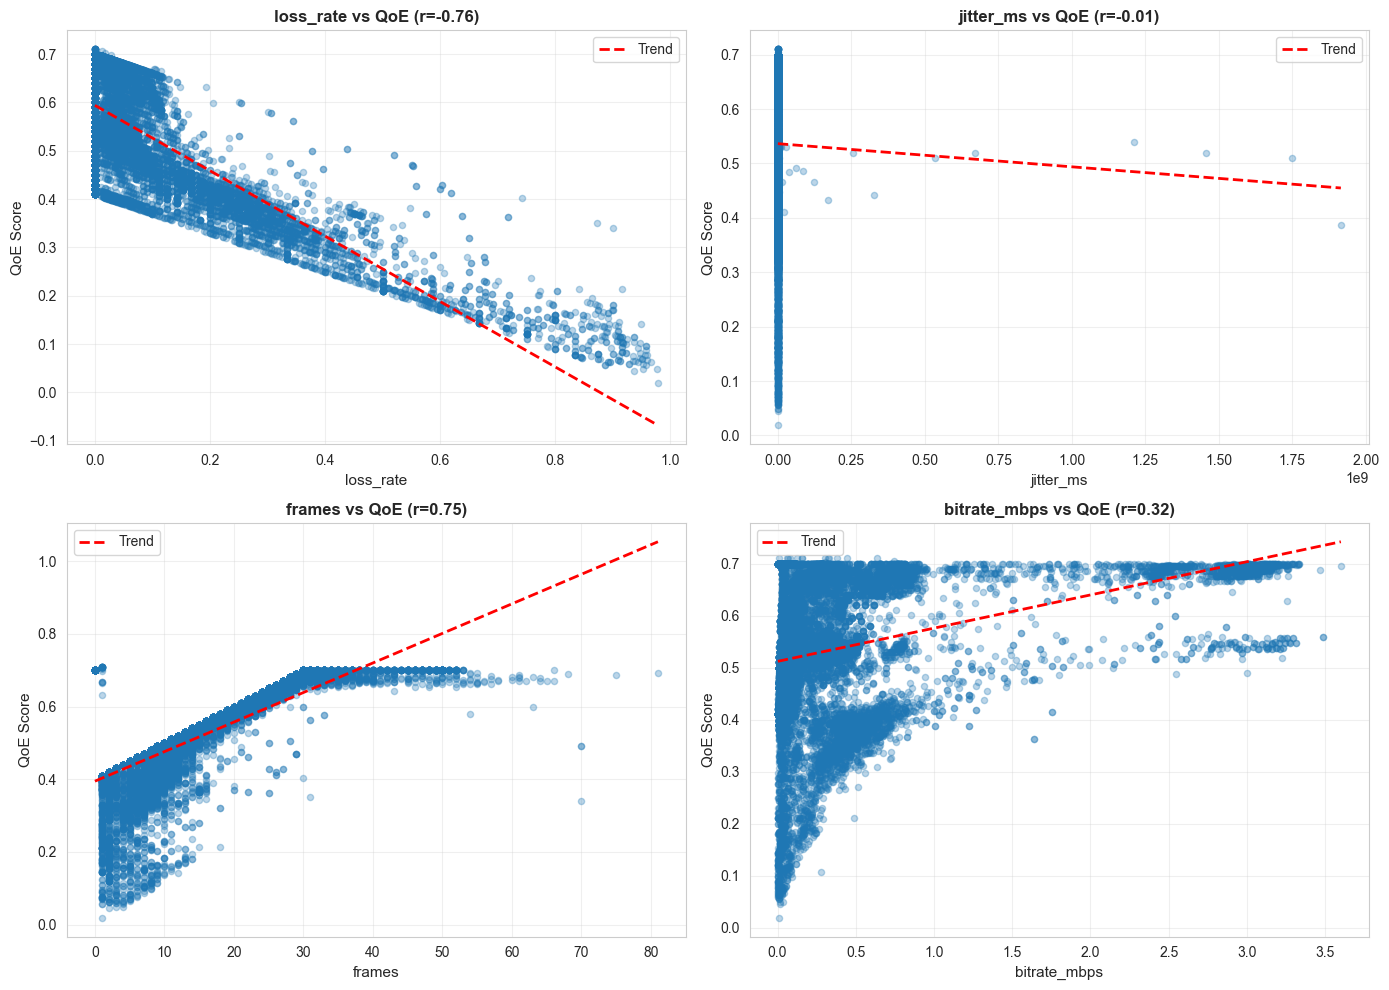

✓ Saved: phase2_metric_vs_qoe_scatter.png


In [17]:
# Create scatter plots: each metric vs QoE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['loss_rate', 'jitter_ms', 'frames', 'bitrate_mbps']
colors_map = {'bad': '#d62728', 'medium': '#ff7f0e', 'good': '#2ca02c'}

for idx, (ax, metric) in enumerate(zip(axes.flatten(), metrics_to_plot)):
    if metric in df.columns:
        # Plot all points
        ax.scatter(df[metric], df['qoe_score'], alpha=0.3, s=20, color='#1f77b4')
        
        # Add trend line
        z = np.polyfit(df[metric].fillna(0), df['qoe_score'].fillna(0), 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[metric].min(), df[metric].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
        
        # Calculate correlation
        corr_coef = df[metric].corr(df['qoe_score'])
        
        ax.set_xlabel(metric, fontsize=11)
        ax.set_ylabel('QoE Score', fontsize=11)
        ax.set_title(f'{metric} vs QoE (r={corr_coef:.2f})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.savefig('phase2_metric_vs_qoe_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: phase2_metric_vs_qoe_scatter.png")

## Section 5: Save Results

In [ ]:
import os
os.makedirs('phase2_results', exist_ok=True)

# Save reaction latencies
if reactions:
    reactions_df = pd.DataFrame(reactions)
    reactions_df.to_csv('phase2_results/reaction_latencies.csv', index=False)
    print("✓ Saved: phase2_results/reaction_latencies.csv")

# Save recovery latencies
if recoveries:
    recoveries_df = pd.DataFrame(recoveries)
    recoveries_df.to_csv('phase2_results/recovery_latencies.csv', index=False)
    print("✓ Saved: phase2_results/recovery_latencies.csv")

# Save correlation matrix
if len(available_cols) >= 3:
    corr_matrix.to_csv('phase2_results/correlation_matrix.csv')
    print("✓ Saved: phase2_results/correlation_matrix.csv")

# Save mode sensitivity summary
mode_summary_df = pd.DataFrame([
    {
        'Mode': mode,
        'Avg_QoE': summary_stats[mode].get('qoe_score', {}).get('mean', 'N/A'),
        'Avg_Loss': summary_stats[mode].get('loss_rate', {}).get('mean', 'N/A'),
        'Avg_FPS': summary_stats[mode].get('frames', {}).get('mean', 'N/A'),
        'Avg_Jitter_ms': summary_stats[mode].get('jitter_ms', {}).get('mean', 'N/A'),
        'Avg_Bitrate_Mbps': summary_stats[mode].get('bitrate_mbps', {}).get('mean', 'N/A'),
        'Brittleness_Pct': brittleness_results.get(mode, {}).get('brittleness_pct', 'N/A')
    }
    for mode in scenarios.keys()
])
mode_summary_df.to_csv('phase2_results/mode_sensitivity_summary.csv', index=False)
print("✓ Saved: phase2_results/mode_sensitivity_summary.csv")

print("\n✅ All Phase 2 analysis results saved!")

✓ Saved: phase2_results/reaction_latencies.csv
✓ Saved: phase2_results/correlation_matrix.csv
✓ Saved: phase2_results/mode_sensitivity_summary.csv

✅ All Phase 2 analysis results saved!


: 

## Summary: Key Findings for Your Paper

### 1. Adaptation & Recovery Latency
- **Reaction Time**: How fast does Zoom detect network problems?
- **Recovery Time**: How long does it take for quality to return to acceptable levels?

### 2. Mode Sensitivity
- Which mode (Screen Share vs Video) is more resilient to WiFi interference?
- Which has the better "brittleness" score?

### 3. Correlation Analysis
- **Strongest predictor**: Which metric (loss, jitter, FPS) best predicts call quality?
- **Bad call characteristics**: What metrics distinguish good vs bad sessions?